# Your own device function and kernel

> Write the arithmetic once as an `AETHER_DEVICEHOST()` function;
> dispatch it yourself with a loop on the CPU, or launch it as a kernel
> on the GPU (optional, at the end).

**Time:** ~8 min · **Runs on:** CPU, GPU switch · **You need:**
[One array, two machines](01_one_array_two_machines),
[Device math](03_device_math),
[Host vs device code](../host_vs_device.rst)

In [1]:
%run ../_shared/setup.py

running on: cpu


`AETHER_DEVICEHOST()` marks an ordinary function so it compiles and
runs correctly whether it is called from plain CPU code or from inside a
GPU kernel. On the CPU, you dispatch it yourself, once per sample, with
an ordinary loop (OpenMP here):

In [2]:
print(run_cpp(r"""
    aether::Array<double, 1> v(6), out(6);
    auto vv = v.hostView();
    for (std::size_t i = 0; i < v.samples(); ++i)
        vv(0, i) = static_cast<double>(i) + 1.0;
    auto ov = out.hostView();
    #pragma omp parallel for
    for (std::size_t i = 0; i < v.samples(); ++i)
        ov(0, i) = speedPenalty(vv(0, i), 0.1);
    std::printf("speedPenalty(2, 0.1) = %g\n", ov(0, 1));
""", top="""
    AETHER_DEVICEHOST() double speedPenalty(double v, double drag)
    { return drag * v * v; }
"""))

speedPenalty(2, 0.1) = 0.4



`speedPenalty` is a plain function here; the `#pragma omp parallel for`
loop is what actually dispatches it, once per sample.

## What you will build (the picture)

The per-sample result from the CPU run above:

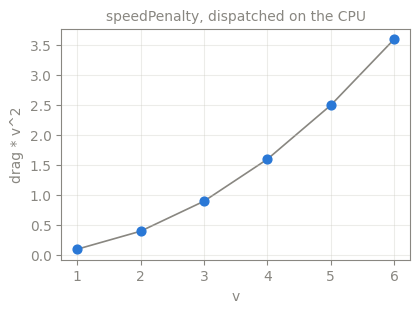

In [3]:
import matplotlib.pyplot as plt
plot_style()

out = run_cpp(r"""
    aether::Array<double, 1> v(6), out(6);
    auto vv = v.hostView();
    for (std::size_t i = 0; i < v.samples(); ++i)
        vv(0, i) = static_cast<double>(i) + 1.0;
    auto ov = out.hostView();
    #pragma omp parallel for
    for (std::size_t i = 0; i < v.samples(); ++i)
        ov(0, i) = speedPenalty(vv(0, i), 0.1);
    for (std::size_t i = 0; i < v.samples(); ++i)
        std::printf("D,%.1f,%.6f\n", vv(0, i), ov(0, i));
""", top="""
    AETHER_DEVICEHOST() double speedPenalty(double v, double drag)
    { return drag * v * v; }
""")
_, cpu_rows = split_data(out)
vs = [float(r[0]) for r in cpu_rows]
penalties = [float(r[1]) for r in cpu_rows]

fig, ax = plt.subplots(figsize=(4.5, 3))
ax.plot(vs, penalties, color="#898781", lw=1.2, zorder=1)
ax.scatter(vs, penalties, color="#2a78d6", s=40, zorder=2)
ax.set_xlabel("v"); ax.set_ylabel("drag * v^2")
ax.set_title("speedPenalty, dispatched on the CPU", color="#898781", fontsize=10)
ax.grid(alpha=0.3)
plt.show()

## What just happened

- `AETHER_DEVICEHOST()` marks a function as legal to call from host code
  and device code with the exact same source line.
- On CPU, you dispatch it yourself with a plain loop (OpenMP here).
- Nothing about `speedPenalty`'s own source names a device anywhere.

## Try this

Change `0.1` (the drag coefficient) in the cell above and re-run: the
printed value changes.

## Next

[Adding a function to aether](05_adding_a_function) -- the macro scaffold
behind `aether::math`'s own dispatch, and how a new one gets added.
*Deeper:* [Host vs device code](../host_vs_device.rst) for the rest of
the device-side vocabulary.

## Going deeper (optional): the same function as a GPU kernel

A GPU version needs a kernel entry point, `AETHER_KERNEL()`, launched
over a 2-level grid of blocks and threads -- `speedPenalty`'s own body
never changes. Inside the kernel, `blockIdx`, `blockDim` and `threadIdx`
are CUDA's own built-ins for "which thread am I": `blockIdx.x *
blockDim.x + threadIdx.x` turns that 2-level grid into the flat sample
index `i` each thread uses to find its own sample.

In [4]:
kernel_top = r"""
    AETHER_DEVICEHOST() double speedPenalty(double v, double drag)
    { return drag * v * v; }

    using Vec1View = aether::Array<double, 1>::ViewT;

    AETHER_KERNEL()
    void speedPenaltyKernel(Vec1View v, Vec1View out, double drag, std::size_t n)
    {
        const std::size_t i = blockIdx.x * blockDim.x + threadIdx.x;
        if (i < n)
            out(0, i) = speedPenalty(v(0, i), drag);
    }
"""
print(kernel_top.strip())

AETHER_DEVICEHOST() double speedPenalty(double v, double drag)
    { return drag * v * v; }

    using Vec1View = aether::Array<double, 1>::ViewT;

    AETHER_KERNEL()
    void speedPenaltyKernel(Vec1View v, Vec1View out, double drag, std::size_t n)
    {
        const std::size_t i = blockIdx.x * blockDim.x + threadIdx.x;
        if (i < n)
            out(0, i) = speedPenalty(v(0, i), drag);
    }


On the host side, `Array<T, Es...>::ViewT` is the device-visible view
type; `.upload()` moves the data to the GPU, and `.deviceView()` hands
back a view pointing at it there:

`aether::cuda::launchConfig(n)` picks a block/thread count for `n`
samples, and `<<<cfg.blocks, cfg.threads>>>` is CUDA's own launch
syntax. This page builds on CPU, so the cell below runs for real only
where a GPU is visible; otherwise it prints a one-line placeholder:

In [5]:
kernel_body = r"""
    aether::Array<double, 1> v(6), out(6);
    auto vv = v.hostView();
    for (std::size_t i = 0; i < v.samples(); ++i)
        vv(0, i) = static_cast<double>(i) + 1.0;
    v.upload();

    const auto cfg = aether::cuda::launchConfig(v.samples());
    speedPenaltyKernel<<<cfg.blocks, cfg.threads>>>(v.deviceView(), out.deviceView(), 0.1, v.samples());
    out.download();
    std::printf("speedPenalty(2, 0.1) = %g\n", out.hostView()(0, 1));
"""
print(run_or_show(kernel_body, top=kernel_top))

(shown, not run: no GPU visible)


Nothing about `speedPenalty`'s own source changes between the CPU loop
and this kernel -- only the dispatch around it does.